In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_predict
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score

In [2]:
#load trained model
class AE(nn.Module):
    def __init__(self, input_size=103, latent_size=10):
        super(AE, self).__init__()
        self.input_size = input_size
        self.latent_size = latent_size

        # encoder network
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 56), nn.ReLU(),
            nn.Linear(56, 28), nn.ReLU(),
            nn.Linear(28, latent_size)
        )
        # decoder network
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, 28), nn.ReLU(),
            nn.Linear(28, 56), nn.ReLU(),
            nn.Linear(56, input_size)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

def load_model(input_size, latent_size):
    model = AE(input_size=input_size, latent_size=latent_size)
    model.load_state_dict(
        torch.load("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Autoencoder/best_autoencoder_nested_cv.pt")
    )
    model.eval()
    return model
model = load_model(103, 10)

In [3]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A1_2_PCA_training_data.csv"

df_training_data = pd.read_csv(path)
df_training_data = df_training_data.iloc[:,1:]

df_unseen_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A2_unseen_data_ukb_adni_o3.csv")
df_unseen_data = df_unseen_data.iloc[:,1:]

full_dataset = pd.concat([df_training_data, df_unseen_data], axis=0)

demographic_data = full_dataset.iloc[:,:5]
brain_features =  full_dataset.iloc[:,5:]

scaler = RobustScaler()

data_scaled = scaler.fit_transform(brain_features)
data_tensor = torch.tensor(data_scaled, dtype=torch.float32)
data_tensor = TensorDataset(data_tensor)
data_loader = DataLoader(data_tensor, batch_size=64, shuffle=False)

In [4]:
latent_vectors = []
with torch.no_grad():
    for batch in data_loader:
        x = batch[0]
        z = model.encode(x)
        latent_vectors.append(z.numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)
latent_df = pd.DataFrame(latent_vectors, columns=[f"latent_{i}" for i in range(1,11)])
latent_df_svm = latent_df.copy()
#latent_df_svm["Diagnosis"] = demographic_data["Diagnosis"]
latent_df_demo = pd.concat([demographic_data.reset_index(drop=True), latent_df], axis=1)

In [5]:
y = latent_df_demo.iloc[:,3]
X = latent_df_demo.iloc[:,5:]

              precision    recall  f1-score   support

         0.0       0.99      0.85      0.92      4510
         1.0       0.25      0.54      0.35       410
         2.0       0.21      0.54      0.31       125

    accuracy                           0.82      5045
   macro avg       0.49      0.64      0.52      5045
weighted avg       0.91      0.82      0.85      5045

[[3834  597   79]
 [  19  221  170]
 [   5   52   68]]
Accuracy: 0.8172447968285431
parameters for C: 1, parameters for gamma: 0.01


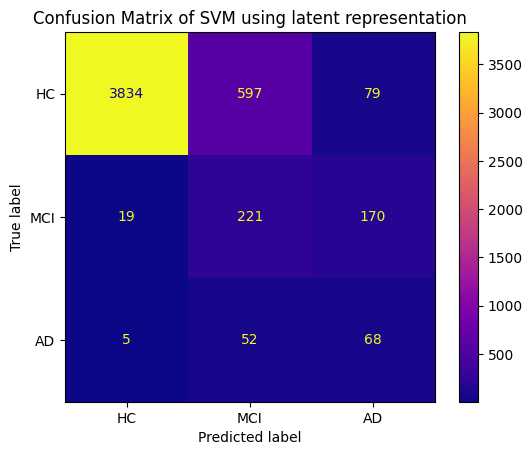

In [6]:
C = 1
gamma = 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)


clf = make_pipeline(StandardScaler(), 
                    SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True)
                   )

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)   
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))  
print(f"parameters for C: {C}, parameters for gamma: {gamma}")

cm = confusion_matrix(y_test, y_pred)
labels = ['HC', 'MCI', 'AD']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM using latent representation')
plt.show()

In [35]:
y_test.value_counts()

Diagnosis
0.0    1804
1.0     164
2.0      50
Name: count, dtype: int64

              precision    recall  f1-score   support

         0.0       0.99      0.85      0.92      4510
         1.0       0.25      0.54      0.35       410
         2.0       0.21      0.54      0.31       125

    accuracy                           0.82      5045
   macro avg       0.49      0.64      0.52      5045
weighted avg       0.91      0.82      0.85      5045

Accuracy: 0.8172447968285431


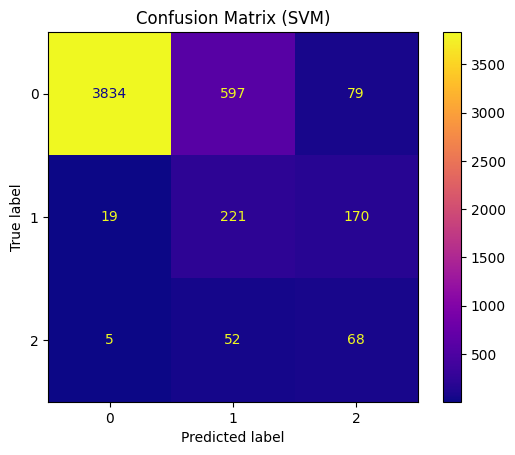

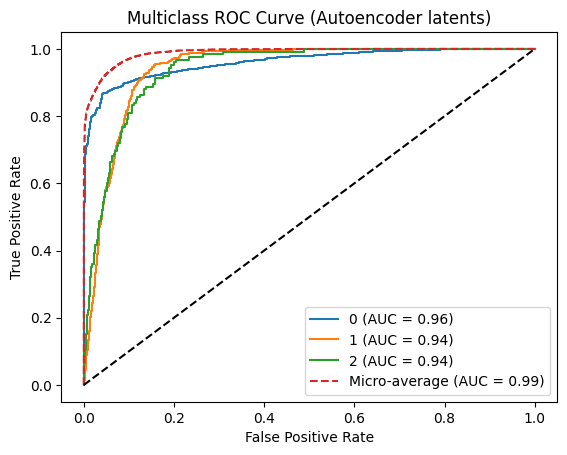

Macro AUC: 0.947
Micro AUC: 0.989


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

C = 1
gamma = 0.01
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

labels = [0, 1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix (SVM)')
plt.show()

y_test_bin = label_binarize(y_test, classes=labels)

y_score = clf.predict_proba(X_test)

n_classes = len(labels)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')

plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (Autoencoder latents)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")


accuracy: 0.833 ± 0.009
precision_macro: 0.515 ± 0.012
recall_macro: 0.680 ± 0.017
f1_macro: 0.558 ± 0.015


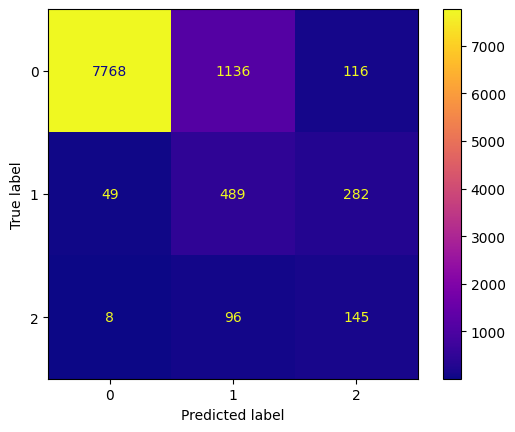

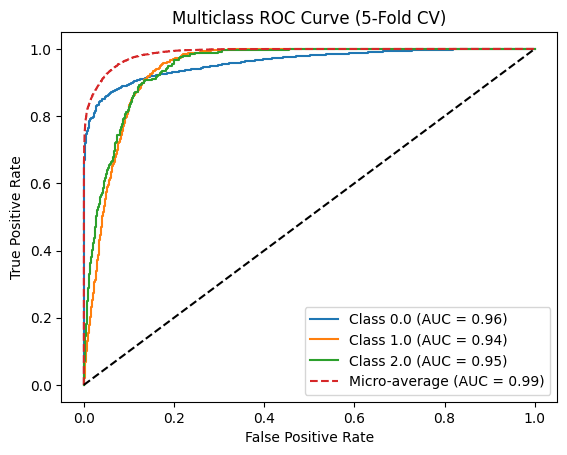

Macro AUC: 0.949
Micro AUC: 0.989


In [8]:
C = 1
gamma = 0.01

clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(clf, X, y, cv=cv, scoring=scoring,return_train_score=False, return_estimator=True)

for metric in scoring.keys():
    print(f"{metric}: {np.mean(cv_results[f'test_{metric}']):.3f} ± {np.std(cv_results[f'test_{metric}']):.3f}")

y_pred = cross_val_predict(clf, X, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='plasma')
plt.show()

y_score = cross_val_predict(clf, X, y, cv=cv, method='predict_proba')
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

n_classes = y_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
macro_auc = roc_auc_score(y_bin, y_score, multi_class='ovr', average='macro')

plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (5-Fold CV)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")

              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96      7105
         2.0       0.08      0.96      0.14        50

    accuracy                           0.92      7155
   macro avg       0.54      0.94      0.55      7155
weighted avg       0.99      0.92      0.95      7155

Accuracy: 0.9189378057302585


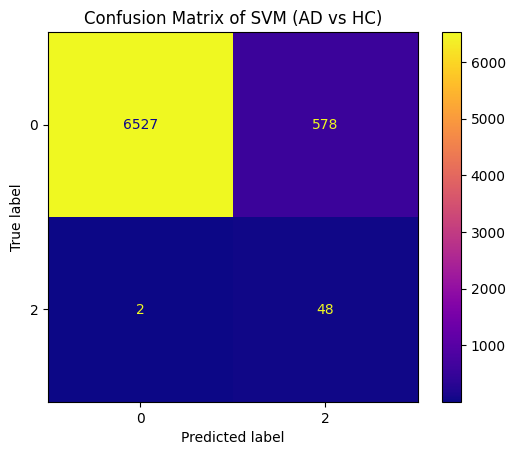

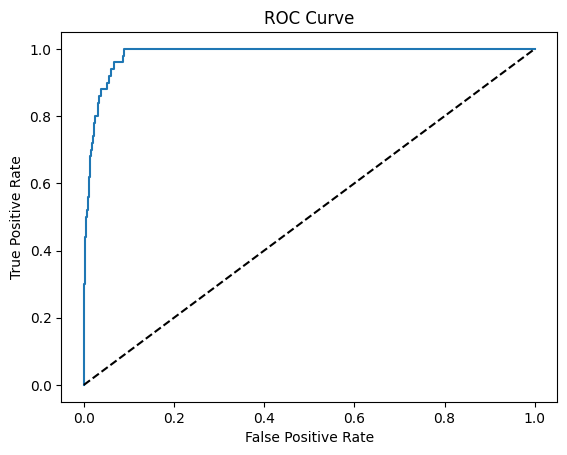

In [35]:
######################
###### AD VS HC ######
######################

ad_vs_hc = latent_df_demo[latent_df_demo["Diagnosis"] != 1]
y = ad_vs_hc.iloc[:,3]
X = ad_vs_hc.iloc[:,5:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 1
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

labels = [0, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM (AD vs HC)')
plt.show()

y_test_binary = (y_test == 2).astype(int)  # AD as positive class
y_pred_binary = (y_pred == 2).astype(int)  # 
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


              precision    recall  f1-score   support

         1.0       0.89      0.57      0.70       164
         2.0       0.35      0.76      0.48        50

    accuracy                           0.62       214
   macro avg       0.62      0.67      0.59       214
weighted avg       0.76      0.62      0.65       214

Accuracy: 0.616822429906542


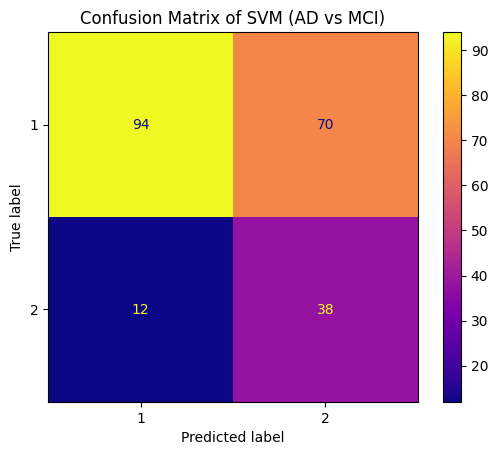

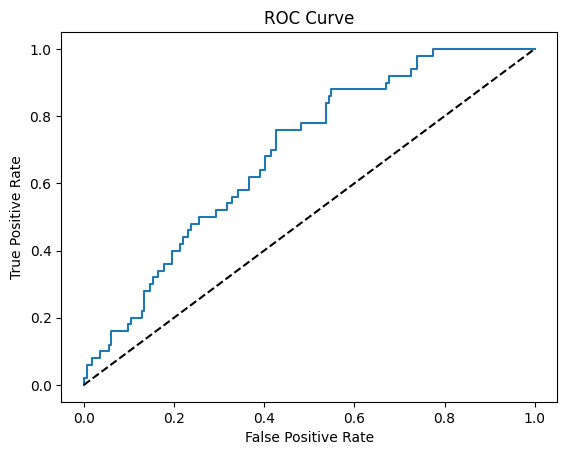

In [55]:
######################
##### AD VS MCI #####
######################

ad_vs_mci = latent_df_demo[latent_df_demo["Diagnosis"] != 0]
y = ad_vs_mci.iloc[:,3]
X = ad_vs_mci.iloc[:,5:]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 2
gamma = 0.01
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))


labels = [1, 2]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM (AD vs MCI)')
plt.show()

y_test_binary = (y_test == 2).astype(int)  # AD as positive class
y_pred_binary = (y_pred == 2).astype(int)  
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

              precision    recall  f1-score   support

         0.0       1.00      0.89      0.94      7105
         1.0       0.17      0.97      0.28       164

    accuracy                           0.89      7269
   macro avg       0.58      0.93      0.61      7269
weighted avg       0.98      0.89      0.93      7269

Accuracy: 0.889806025588114


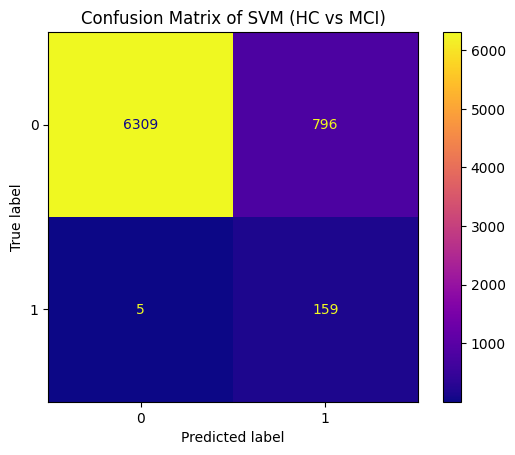

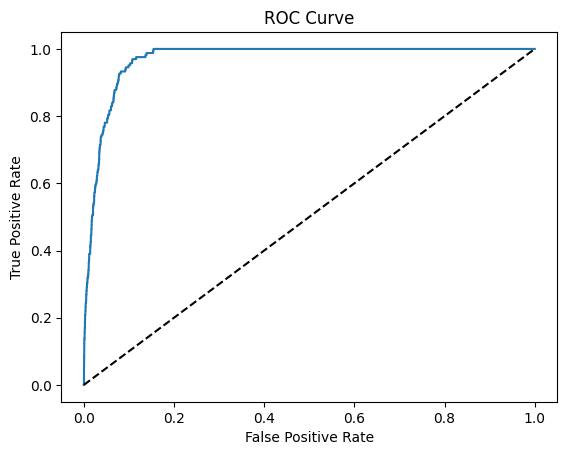

In [7]:
######################
###### MCI VS HC ######
######################

hc_vs_mci = latent_df_demo[latent_df_demo["Diagnosis"] != 2]
y = hc_vs_mci.iloc[:,3]
X = hc_vs_mci.iloc[:,5:]
labels = [0, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

C = 2
gamma = 0.01
clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced', probability=True))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))

cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM (HC vs MCI)')
plt.show()

y_test_binary = (y_test == 1).astype(int)  # MCI as positive class
y_pred_binary = (y_pred == 1).astype(int)  # 
y_score = clf.predict_proba(X_test)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()